### Standardisation
### Normalisationn
### Encoding----> all 4
### CCA
### Column Transformer
### Pipeline


In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  
from sklearn.preprocessing import StandardScaler,MinMaxScaler 


In [ ]:
df=pd.read_csv("C:\\Users\\HARSHITA\\OneDrive\\Data_sets\\insurance - insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Outliers Handling

In [89]:
# first checking the outliers ? 

<Axes: xlabel='charges'>

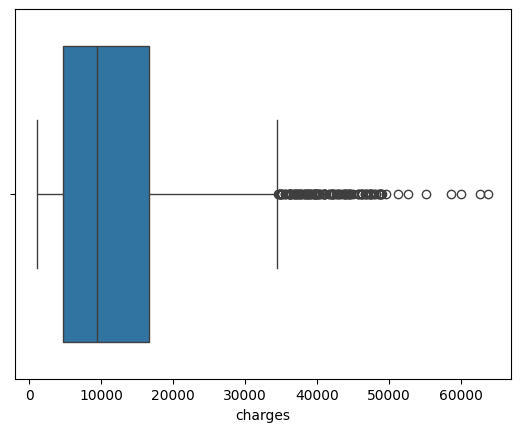

In [90]:
sns.boxplot(x=df['charges'])

<Axes: xlabel='bmi'>

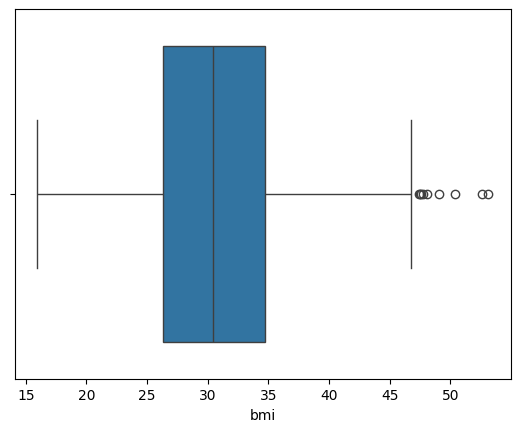

In [91]:
sns.boxplot(x=df['bmi'])

In [92]:
# for charges feature 

In [93]:
percentile25=df['charges'].quantile(0.25)
percentile25
percentile75=df['charges'].quantile(0.75)
percentile75
IQR=percentile75-percentile25
IQR
Upper_limit= percentile75+1.5*IQR
Upper_limit
Lower_limit=percentile25-1.5*IQR
Lower_limit

np.float64(-13109.1508975)

In [94]:
# for bmi feature

In [95]:
percentile25=df['bmi'].quantile(0.25)
percentile25
percentile75=df['bmi'].quantile(0.75)
percentile75
IQR=percentile75-percentile25
IQR
Upper_limit_bmi= percentile75+1.5*IQR
Upper_limit_bmi
Lower_limit_bmi=percentile25-1.5*IQR
Lower_limit_bmi

np.float64(13.7)

In [96]:
df[df['charges']>Upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [97]:
df[df['charges']>Upper_limit_bmi]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [98]:
### Handling it with capping

In [99]:
newdf=df.copy()

In [100]:
#for charges feature

In [101]:
newdf['charges']=np.where(newdf['charges']>Upper_limit,Upper_limit,
                          np.where(newdf['charges']<Lower_limit,Lower_limit,
                          newdf['charges']))

In [102]:
# for bmi column

In [103]:
newdf['bmi']=np.where(newdf['bmi']>Upper_limit_bmi,Upper_limit_bmi,
                          np.where(newdf['bmi']<Lower_limit_bmi,Lower_limit_bmi,
                          newdf['bmi']))

In [104]:
# checking the difference in df and new_df for outliers 

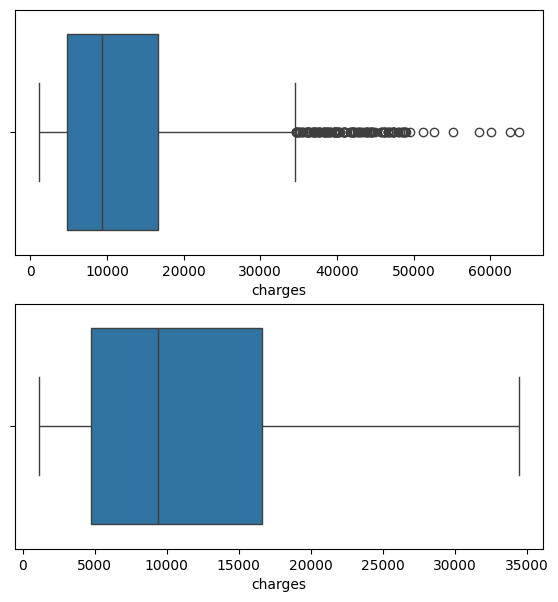

In [105]:
plt.figure(figsize=(15,7))
plt.subplot(222)
sns.boxplot(x=df['charges'])

plt.subplot(224)
sns.boxplot(x=newdf['charges'])
plt.show()

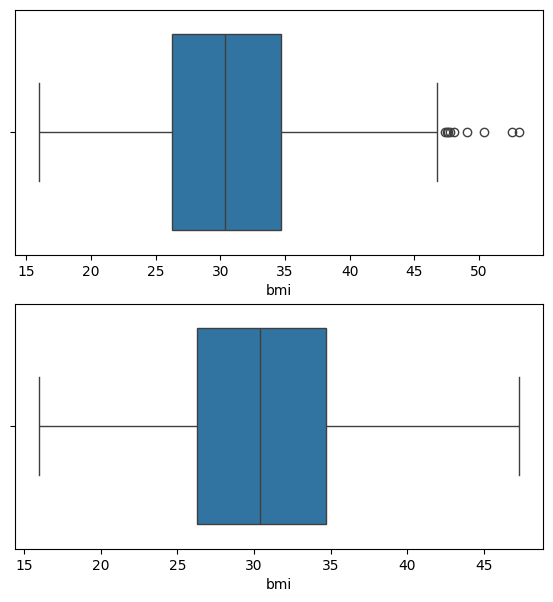

In [106]:
plt.figure(figsize=(15,7))
plt.subplot(222)
sns.boxplot(x=df['bmi'])

plt.subplot(224)
sns.boxplot(x=newdf['bmi'])
plt.show()

### spliting the data

In [107]:
x=df.drop(columns=['charges'])
y=df['charges']

In [108]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Encoding

In [109]:
# Label encoding

In [110]:
le=LabelEncoder()

In [113]:
x_train['sex']=le.fit_transform(x_train['sex'])
x_train['smoker']=le.fit_transform(x_train['smoker'])
x_train['region']=le.fit_transform(x_train['region'])

In [114]:
### Ordinal Encoding

In [120]:
# oe=OrdinalEncoder(categories=[['female', 'male'],['yes', 'no'],['southwest', 'southeast', 'northwest', 'northeast']])
# x_train_oe=oe.fit_transform(x_train)

In [121]:
### Onehot Encoding

In [122]:
# ohe=OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
# ohe.fit_transform(x_train[['sex','area','region']])


In [123]:
### get_dummies 

In [ ]:
# a=pd.get_dummies(df,columns=['sex','area','region'],drop_first=True)
# a=a.astype(int)

In [127]:
x_train.shape

(1070, 6)

In [126]:
x_test.shape

(268, 6)

### Standardisation

In [129]:
sc=StandardScaler()

In [130]:
x_train_sc=sc.fit_transform(x_train)

In [131]:
df_new=pd.DataFrame(x_train_sc,columns=x_train.columns)

In [133]:
np.round(df_new.describe(),2)

,age,sex,bmi,children,smoker,region
count,1070.00,1070.00,1070.00,1070.00,1070.00,1070.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.52,-1.02,-2.42,-0.91,-0.51,-1.35
25%,-0.88,-1.02,-0.72,-0.91,-0.51,-0.46
50%,0.01,0.98,-0.06,-0.09,-0.51,0.44
75%,0.83,0.98,0.65,0.73,-0.51,0.44
max,1.75,0.98,3.74,3.20,1.97,1.34


In [134]:
### MinMaxScaler

In [ ]:
# mn=MinMaxScaler()
#x_train_mn=mn.fit_transform(x_train)
#df_new_2=pd.DataFrame(x_train_sc,columns=x_train.columns)
#np.round(df_new_2.describe(),2)

### Column Transformer

In [142]:
df=pd.read_csv("C:\\Users\\HARSHITA\\OneDrive\\Data_sets\\insurance - insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [143]:
x=df.drop(columns=['charges'])
y=df['charges']

In [144]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [145]:
numerical_columns=df.select_dtypes(exclude=['object']).columns

In [146]:
categorical_columns=df.select_dtypes(include=['object']).columns

In [147]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)],remainder='passthrough'   )

In [148]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
])
